In [1]:
import pypsa
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
regions = gpd.read_file(
    Path.cwd().parent / 'resources' / 'regions_onshore_base_s_50.geojson'
).set_index('name')

regions_plot = regions.copy().to_crs(epsg=4258)

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


In [14]:
def get_buses(buses):
    buses = pd.Index(buses)
    return buses.str.split().str[:2].str.join(' ')

In [18]:
template = 'base_s_50__3H-T-H-B-I-A-dist1_2035_free_{}.nc'

In [20]:
wiggles = list(range(0, 4250, 250))

capex_df = list()
opex_df = list()

for w in wiggles:

    n = pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' /
        template.format(w)
        )

    c = n.statistics.capex(groupby=['carrier', 'bus'])
    c = c.groupby(get_buses(c.index.get_level_values(2))).sum()
    c = c.loc[~c.index.str.contains('EU')]

    o = n.statistics.opex(groupby=['carrier', 'bus'])
    o = o.groupby(get_buses(o.index.get_level_values(2))).sum()
    o = o.loc[~o.index.str.contains('EU')]
    o = o.loc[~o.index.str.contains('atmosphere')]

    capex_df.append(c.rename(w))
    opex_df.append(o.rename(w))

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_0.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_250.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_750.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_1000.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_free_1250.nc has buses, carriers, generators, global_constraints,

In [21]:
cc = pd.concat(capex_df, axis=1)
oo = pd.concat(opex_df, axis=1)

In [27]:
tt = cc + oo

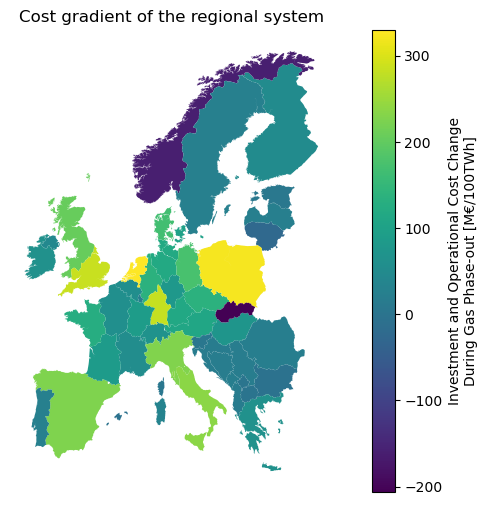

In [32]:
lower, upper = 0, len(tt.columns) - 1
cost_gradient = (tt.iloc[:,lower] - tt.iloc[:,upper]) / (tt.columns[upper] - tt.columns[lower]) / 1e6 * 1e2

fig, ax = plt.subplots(figsize=(10, 6))

regions_plot['value'] = cost_gradient
regions_plot.plot(ax=ax, column='value', cmap='viridis', legend=True, 
                  legend_kwds={'label': 'Investment and Operational Cost Change\nDuring Gas Phase-out [M€/100TWh]'})

ax.set_xlabel('')
ax.set_title('Cost gradient of the regional system')

ax.set_axis_off()

plt.show()

<Axes: >

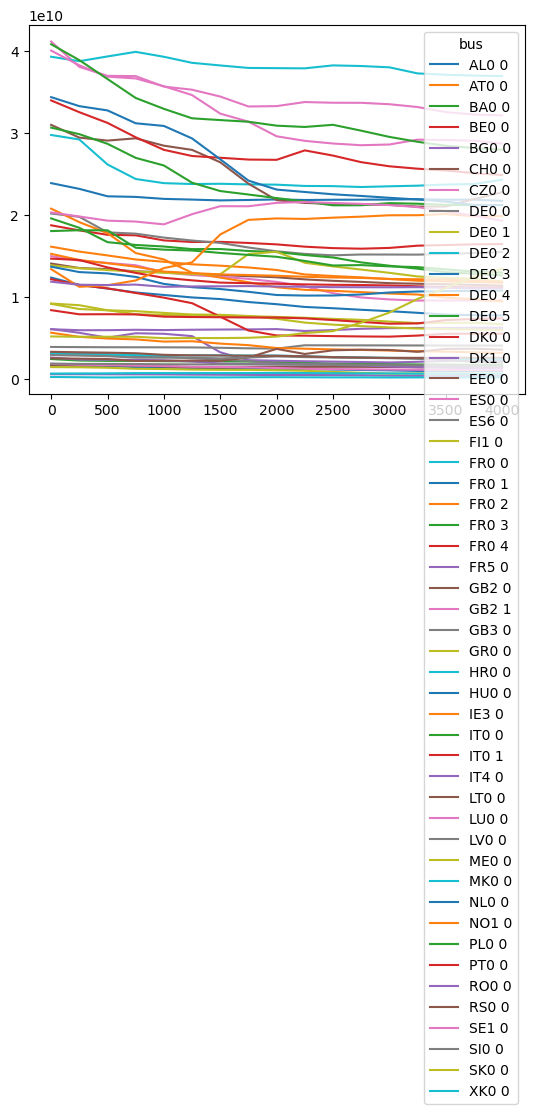

In [33]:
tt.T.plot()